In [12]:
from model_ranking import (
    load_h5,
)
import numpy as np
import matplotlib.pyplot as plt

In [13]:
ov_gt_path = "/scratch/talks/data/Ovules/GT2x/N_294_final_crop_ds2_patchwise.h5"
ov_gt_patched = load_h5(ov_gt_path, "label")

In [14]:
non_empty_ids = []
for i in range(ov_gt_patched.shape[0]):
    foreground_ratio = np.sum(ov_gt_patched[i] > 0) / np.prod(ov_gt_patched[i].shape)
    if foreground_ratio > 0:
       non_empty_ids.append(i)
print(len(non_empty_ids))

3452


In [27]:
unp_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5"

#ARE_consis_scores = load_h5(p_path, "AdaRandError_consis")[non_empty_ids]
ARE_consis_scores = load_h5(p_path, "AdaRandError_consis")

In [28]:
print(ARE_consis_scores.shape)

(5120, 3)


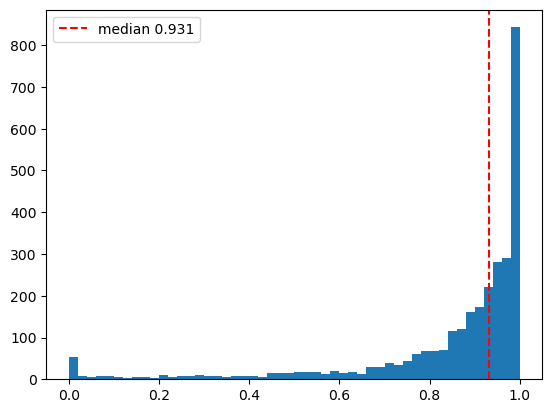

In [29]:
med_consis = 1 - np.nanmedian(ARE_consis_scores[:, 0])
plt.hist(1 - ARE_consis_scores[:, 0], bins=50)
plt.axvline(med_consis, color="r", label=f"median {med_consis:.3f}", linestyle="--")
plt.legend()
plt.show()

In [31]:
#p_seg = load_h5(p_path, "segmentation")[non_empty_ids]
p_seg = load_h5(p_path, "segmentation")
p_foreground_ratios = []
for i in range(p_seg.shape[0]):
    foreground_ratio = np.sum(p_seg[i] > 0) / np.prod(p_seg[i].shape)
    p_foreground_ratios.append(foreground_ratio)

In [32]:
#unp_seg = load_h5(unp_path, "segmentation")[non_empty_ids]
unp_seg = load_h5(unp_path, "segmentation")
unp_foreground_ratios = []
for i in range(unp_seg.shape[0]):
    foreground_ratio = np.sum(unp_seg[i] > 0) / np.prod(unp_seg[i].shape)
    unp_foreground_ratios.append(foreground_ratio)

In [33]:
cmb_foreground_ratios = np.stack((p_foreground_ratios, unp_foreground_ratios))
print(cmb_foreground_ratios.shape)

(2, 5120)


In [34]:
mean_f_ratio = np.mean(cmb_foreground_ratios, axis=0)
print(mean_f_ratio.shape)

(5120,)


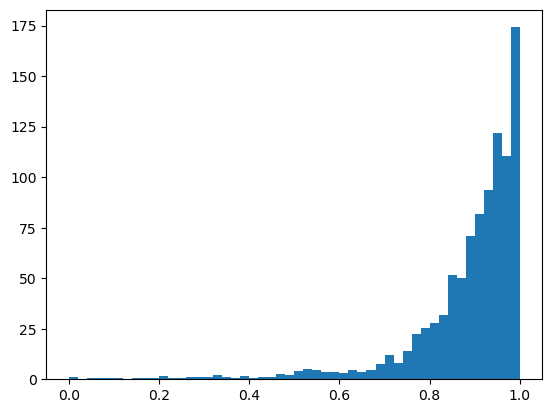

In [45]:
plt.hist(1 - ARE_consis_scores[:, 0], bins=50, weights=mean_f_ratio)
plt.show()

In [37]:
# Handle NaN values by creating masks for valid data
valid_mask = ~np.isnan(ARE_consis_scores[:, 0])
valid_consis_scores = 1 - ARE_consis_scores[valid_mask, 0]
valid_weights = mean_f_ratio[valid_mask]

print(valid_consis_scores.shape, valid_weights.shape)

# Calculate weighted average (not median, as np.average computes weighted mean)
weighted_mean_consis = np.average(valid_consis_scores, weights=valid_weights)
print(f"Weighted mean consistency score: {weighted_mean_consis:.3f}")

(3029,) (3029,)
Weighted mean consistency score: 0.885


In [38]:
(valid_consis_scores * valid_weights).sum() / valid_weights.sum()

0.8848434720582018

In [41]:
path_pred = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5"
path_summary = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/metric_summary_full.h5"
foreground_ratios = load_h5(path_pred, "avg_foreground_ratio")
weighted_avg_consis = load_h5(path_summary, "weighted_AdaRandError_consis")
print(f"Weighted average consistency from file: {1 - weighted_avg_consis:.5f}")
print(f"Weighted mean consistency score computed here: {weighted_mean_consis:.5f}")

Weighted average consistency from file: 0.88484
Weighted mean consistency score computed here: 0.88484


In [44]:
np.isclose(foreground_ratios, mean_f_ratio).all()

True

In [36]:
def weighted_average_consistency(consis_scores, weights):
    valid_mask = ~np.isnan(consis_scores[:, 0])
    valid_consis_scores = consis_scores[valid_mask, 0]
    valid_weights = weights[valid_mask]
    return np.average(valid_consis_scores, weights=valid_weights)

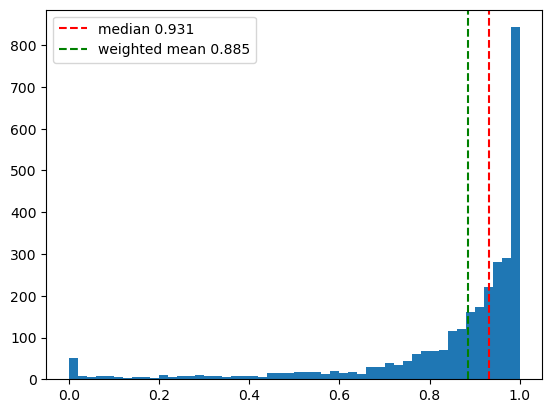

In [26]:
med_score = np.nanmedian(1 - ARE_consis_scores[:, 0])
plt.hist(1- ARE_consis_scores[:, 0], bins=50)
plt.axvline(med_score, color="r", label=f"median {med_score:.3f}", linestyle="--")
plt.axvline(weighted_mean_consis, color="g", label=f"weighted mean {weighted_mean_consis:.3f}", linestyle="--")
plt.legend()
plt.show()

In [8]:
from model_ranking import MODEL_ABBREVIATIONS_TO_DATASET 
from pathlib import Path

def get_output_pred_paths(
    target: str,
    model_name: str,
    run_id: str,
    approach: str = "consistency",
    base_path: str = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells",
):
    source = MODEL_ABBREVIATIONS_TO_DATASET[model_name.split("_")[0]]

    output_paths = list((Path(base_path) / f"{source}_to_{target}_gap/{approach}/{run_id}/{model_name}").rglob("**/*predictions.h5"))
    return output_paths

In [9]:
output_paths = get_output_pred_paths(
    target="Ovules",
    model_name="fw_model_Unet2",
    run_id="P2",
)
print(len(output_paths))

6


In [11]:
output_paths

[PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a001-005/predictions/N_294_final_crop_ds2_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a005-01/predictions/N_294_final_crop_ds2_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a015-02/predictions/N_294_final_crop_